In [1]:
import pandas as pd

In [2]:
#Data Loading
df=pd.read_csv(r"C:\Users\Admin\Downloads\q3_retail_promotions.csv")

In [3]:
df

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249
3,2022-01-02,17,small,urban,free_gift,1,0,7,259
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277
...,...,...,...,...,...,...,...,...,...
1195,2024-12-28,39,large,urban,bogo,1,0,3,384
1196,2024-12-28,44,medium,urban,category_offer,1,0,9,371
1197,2024-12-29,47,large,semi-urban,bogo,1,0,7,367
1198,2024-12-31,25,small,urban,bogo,0,0,6,321


In [5]:
df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249
3,2022-01-02,17,small,urban,free_gift,1,0,7,259
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277


In [6]:
#Date Feature Engineering
# Convert to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Extract features
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

# Month end flag
df['is_month_end'] = df['transaction_date'].dt.day >= 25
df['is_month_end'] = df['is_month_end'].astype(int)

df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


### Date Feature Engineering

- Extracted `year`, `month`, and `day_of_week` from the transaction date
- Created a new feature `is_month_end` to capture end-of-month shopping behavior
- These features help capture temporal patterns in sales

**Insight:**  
Customer purchasing behavior often varies by time (weekends, month-end, festivals), making temporal features important for prediction.

In [7]:
#Temporal train-test split
# Sort by date
df = df.sort_values(by='transaction_date')

# Split index
split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

train_df.shape, test_df.shape

((960, 13), (240, 13))

### Temporal Train-Test Split

- The dataset was split based on time order:
  - First 80% → Training set
  - Last 20% → Test set

**Why not random split?**
- Random splitting breaks the time sequence
- Causes data leakage from future to past
- Produces unrealistic model performance

**Conclusion:**  
Time-based splitting ensures the model is evaluated on future unseen data, mimicking real-world scenarios.

In [8]:
#Preprocessing Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Features & target
target = 'items_sold'

X_train = train_df.drop(columns=[target, 'transaction_date'])
y_train = train_df[target]

X_test = test_df.drop(columns=[target, 'transaction_date'])
y_test = test_df[target]

# Categorical & numerical columns
categorical_cols = ['promotion_type', 'location_type', 'store_size']
numerical_cols = [col for col in X_train.columns if col not in categorical_cols]

# Preprocessing
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first'), categorical_cols),
    ('num', StandardScaler(), numerical_cols)
])

In [10]:
X_test

,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,year,month,day_of_week,is_month_end
960,39,medium,semi-urban,category_offer,0,0,8,2024,6,2,0
961,40,medium,semi-urban,free_gift,0,0,8,2024,6,3,0
962,17,large,urban,category_offer,0,1,9,2024,6,4,0
963,37,small,semi-urban,loyalty_points,1,0,6,2024,6,5,0
964,39,medium,rural,free_gift,1,0,6,2024,6,5,0
...,...,...,...,...,...,...,...,...,...,...,...
1195,39,large,urban,bogo,1,0,3,2024,12,5,1
1196,44,medium,urban,category_offer,1,0,9,2024,12,5,1
1197,47,large,semi-urban,bogo,1,0,7,2024,12,6,1
1198,25,small,urban,bogo,0,0,6,2024,12,1,1


In [11]:
y_test

960     237
961     188
962     440
963     220
964     235
       ... 
1195    384
1196    371
1197    367
1198    321
1199    296
Name: items_sold, Length: 240, dtype: int64

In [12]:
#Model Training and Evaluation
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Pipelines
lr_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LinearRegression())
])

rf_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

# Train
lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['promotion_type',
                                                   'location_type',
                                                   'store_size']),
                                                 ('num', StandardScaler(),
                                                  ['store_id', 'is_weekend',
                                                   'is_festival',
                                                   'competition_density',
                                                   'year', 'month',
                                                   'day_of_week',
                                                   'is_month_end'])])),
                ('model', RandomForestRegressor(random_state=42))])

In [13]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Predictions
lr_pred = lr_pipeline.predict(X_test)
rf_pred = rf_pipeline.predict(X_test)

# Metrics
def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    
    print(f"\n{name}")
    print("RMSE:", rmse)
    print("MAE:", mae)

evaluate("Linear Regression", y_test, lr_pred)
evaluate("Random Forest", y_test, rf_pred)


Linear Regression
RMSE: 27.12145116489062
MAE: 21.052926674588395

Random Forest
RMSE: 31.660007317329118
MAE: 24.87391666666667


### Model Evaluation

The performance of Linear Regression and Random Forest models was evaluated using RMSE and MAE.

#### Linear Regression
- **RMSE:** 27.12  
- **MAE:** 21.05  
- Demonstrates lower error values compared to Random Forest  
- Indicates better predictive accuracy on this dataset  

#### Random Forest
- **RMSE:** 31.66  
- **MAE:** 24.87  
- Shows higher error values, indicating relatively weaker performance  

### Model Comparison and Selection

- Linear Regression outperforms Random Forest in both RMSE and MAE  
- Lower RMSE indicates fewer large prediction errors  
- Lower MAE indicates better average prediction accuracy  

**Conclusion:**  
Linear Regression is the better-performing model for this task.  
This suggests that the relationship between features and `items_sold` is relatively **linear**, and a simpler model is sufficient to capture the underlying patterns.

### Key Insight

- More complex models like Random Forest do not always guarantee better performance  
- Simpler models can perform better when the data has strong linear relationships  

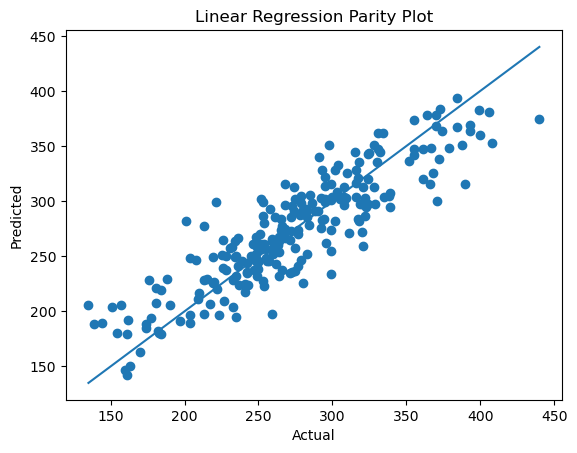

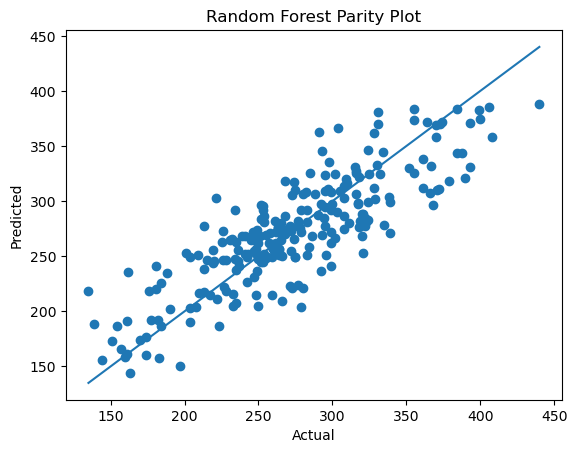

In [14]:
import matplotlib.pyplot as plt

# Linear Regression plot
plt.scatter(y_test, lr_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title("Linear Regression Parity Plot")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

# Random Forest plot
plt.scatter(y_test, rf_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title("Random Forest Parity Plot")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

In [15]:
feature_names = rf_pipeline.named_steps['preprocessing'].get_feature_names_out()

importances = rf_pipeline.named_steps['model'].feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_importance_df.head(10)

,Feature,Importance
7,cat__store_size_small,0.183954
10,num__is_festival,0.174477
5,cat__location_type_urban,0.140498
14,num__day_of_week,0.090612
9,num__is_weekend,0.063547
8,num__store_id,0.062056
6,cat__store_size_medium,0.058178
11,num__competition_density,0.053486
13,num__month,0.040473
4,cat__location_type_semi-urban,0.038886


### Feature Importance Insights

The Random Forest model provides insights into the most influential factors affecting `items_sold`.

#### Top Influential Features

1. **store_size_small (0.184)**  
   - Smaller stores have a strong impact on sales volume  
   - Suggests store size plays a key role in customer purchasing behavior  

2. **is_festival (0.174)**  
   - Festival periods significantly boost sales  
   - Indicates strong seasonal demand patterns  

3. **location_type_urban (0.140)**  
   - Urban stores contribute more to sales compared to other locations  
   - Reflects higher customer footfall and demand in urban areas  

4. **day_of_week (0.091)**  
   - Sales vary across different days of the week  
   - Captures weekly shopping patterns  

5. **is_weekend (0.064)**  
   - Weekends show increased customer activity and purchases  

### Additional Observations

- **store_id (0.062)** suggests store-specific behavior influences sales  
- **store_size_medium (0.058)** also contributes but less than small stores  
- **competition_density (0.053)** indicates local competition impacts sales  
- **month (0.040)** reflects seasonal trends  
- **location_type_semi-urban (0.039)** shows moderate influence  

### Business Insights

- Sales are heavily influenced by **store characteristics, timing, and location**
- Festivals and weekends are key drivers of higher sales
- Urban and smaller stores show distinct purchasing patterns

**Conclusion:**  
Retailers should focus on **festival promotions, weekend strategies, and location-specific planning** to maximize sales performance.